# HR Attrition Prediction - Machine Learning Model

This notebook builds a Logistic Regression model to predict employee attrition, using the same HR Data.xlsx dataset as the Tableau dashboard and the hypothesis testing notebook in this repository.

## Objective
Train and evaluate a classification model that predicts whether an employee is likely to leave, based on demographic, compensation, and satisfaction features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_excel('HR Data.xlsx')
df.shape

(1470, 39)

## Data Preparation

Selecting 14 features spanning demographics, compensation, tenure, and satisfaction, and encoding categorical columns.

In [2]:
features = ['Age', 'Monthly Income', 'Distance From Home', 'Total Working Years',
            'Years At Company', 'Job Satisfaction', 'Environment Satisfaction',
            'Work Life Balance', 'Job Level', 'Num Companies Worked',
            'Over Time', 'Business Travel', 'Marital Status', 'Department']

X = df[features].copy()
y = (df['Attrition'] == 'Yes').astype(int)

cat_cols = ['Over Time', 'Business Travel', 'Marital Status', 'Department']
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

### Handling Class Imbalance
Only 16.12% of employees left, so the model uses class_weight='balanced' to avoid simply predicting "No Attrition" for everyone.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [4]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

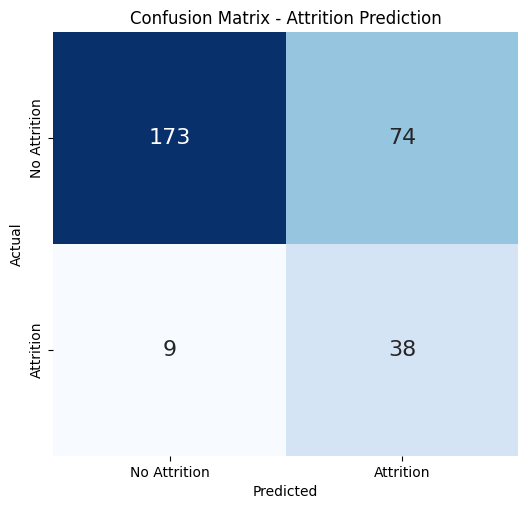

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition','Attrition'],
            yticklabels=['No Attrition','Attrition'],
            cbar=False, annot_kws={'size':16})
plt.title("Confusion Matrix - Attrition Prediction")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [6]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))

Accuracy: 0.717687074829932
Precision: 0.3392857142857143
Recall: 0.8085106382978723
F1: 0.4779874213836478


### Insight
Accuracy = 71.8%, Precision = 33.9%, Recall = 80.9%, F1 = 47.8%. The model catches about 4 out of 5 employees who actually leave (high recall), at the cost of also flagging some employees who were not at risk (lower precision) - a reasonable trade-off for a retention use case, where missing a real flight risk is costlier than a false alarm.

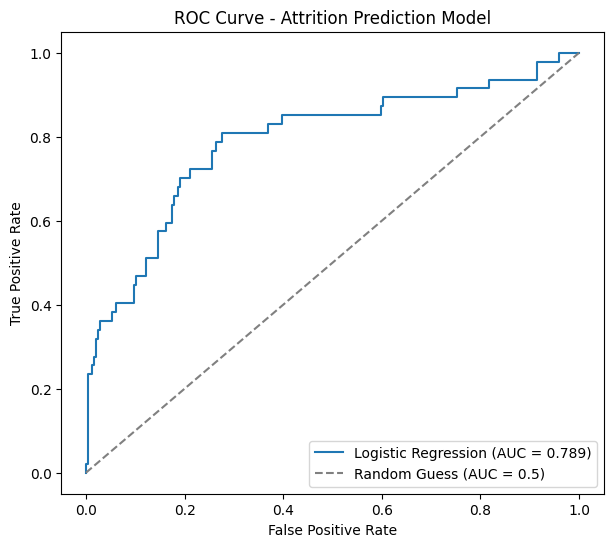

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Attrition Prediction Model')
plt.legend(loc='lower right')
plt.show()

### Insight
ROC AUC = 0.789, meaningfully better than random guessing, and a reasonable result for a first-pass baseline model on real-world HR data.

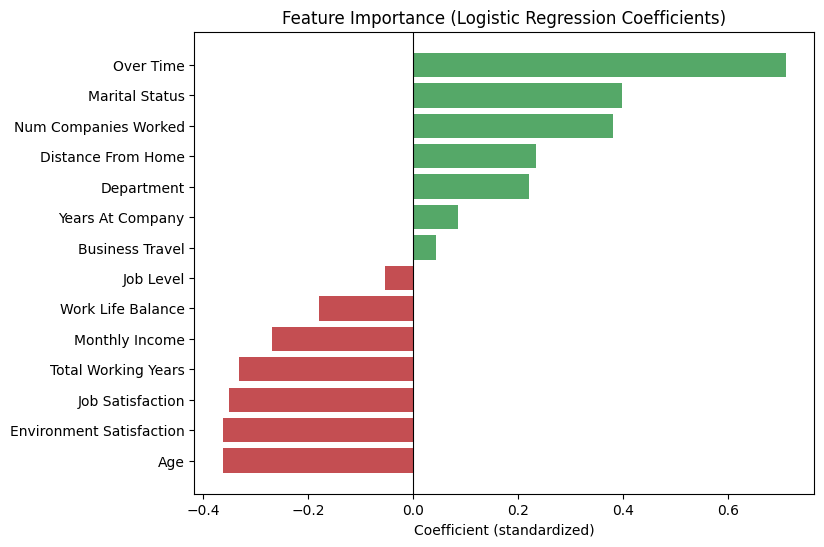

In [8]:
coefs = pd.Series(model.coef_[0], index=features).sort_values()

plt.figure(figsize=(8,6))
colors = ['#C44E52' if c < 0 else '#55A868' for c in coefs.values]
plt.barh(coefs.index, coefs.values, color=colors)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient (standardized)")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

### Insight
Over Time is by far the strongest predictor of attrition, consistent with the chi-square result from the hypothesis testing notebook. Age, Environment Satisfaction, Job Satisfaction, and Monthly Income show the strongest negative association - higher values on each are linked to lower attrition risk.

## Conclusion
This Logistic Regression model achieves an ROC AUC of 0.789 and identifies over 80% of employees who actually left, using just 14 features. Overtime and compensation emerge as the strongest, most actionable predictors - consistent with the earlier hypothesis testing results. Next steps for improvement include addressing class imbalance with techniques like SMOTE, testing tree-based models (Random Forest, Gradient Boosting) to capture non-linear feature interactions, and using cross-validation for more robust evaluation.